<div align="center">

# Exploration : résidu de vocodeur comme feature de pathologie vocale
## Mel → Vocos (pré-entraîné) → resynthèse → résidu → jitter/shimmer/HNR/CPPS

</div>

**Idée :** un vocodeur neuronal pré-entraîné resynthétise la
voix à partir de son mel-spectrogramme. Le **résidu** (signal original − signal resynthétisé) est ce
que le pipeline mel→vocodeur *ne peut pas* reproduire — bruit glottique, apériodicité, souffle. C'est
plausiblement là que vit une partie du signal pathologique fin (raucité, fuite glottique) qui se noie
dans le signal complet. Ceci reprend le schéma « soustraire la sortie d'un modèle prédictif du signal
réel, puis analyser ce qu'il reste » déjà utilisé (résidu AR + détail/approximation en ondelettes) sur
un projet précédent.

Ce notebook fait tourner le pipeline de bout en bout sur un **petit échantillon illustratif de vraies
voyelles /a/ soutenues** — patients pathologiques FOCH (`PR`, `LMB`, `fuite glottique`) + témoins sains
Saarbruecken (SVD) — plutôt que sur de l'audio synthétique. `N_PER_CLASS` enregistrements par groupe
seulement (Section 1) : assez pour **écouter et regarder** ce que le vocodeur fait réellement à une voix
pathologique, pas un échantillon statistiquement représentatif. Les identifiants patient
(`Last_Name`/`File_Name`) ne servent qu'à sélectionner les fichiers sur disque ; seuls des libellés
pseudonymes (`PR_01`, `Healthy_02`, ...) apparaissent dans les sorties (graphiques, lecteurs audio,
tableaux) du notebook.

| Section | Contenu |
|---|---|
| 1 | Configuration (chemins, paramètres du vocodeur, chemins des données réelles) |
| 2 | Signaux réels (échantillon de voyelles /a/ FOCH pathologiques + SVD saines) |
| 3 | Extraction mel — paramètres exacts du vocodeur |
| 4 | Resynthèse par le vocodeur pré-entraîné |
| 5 | Calcul du résidu (original − resynthétisé) |
| 6 | Features Praat (jitter/shimmer/HNR/CPPS) sur original vs. résidu |
| 7 | Comparaison de groupes (Healthy vs. PR / LMB / fuite glottique) |
| 8 | Smoke tests après chaque étape majeure |
| 9 | Journal des modifications |

## 1. Configuration

In [1]:
# ── Vocoder & signal parameters ─────────────────────────────────────────────────
import os

DEVICE = "cpu"  # inference-only (no training) -> CPU is enough; the whole notebook must run without a GPU

# Vocos (https://github.com/gemelo-ai/vocos) -- pip-installable, pretrained checkpoints on the HF Hub.
# Checkpoint git-cloned locally rather than loaded via Vocos.from_pretrained(repo_id): the HF Hub
# Python client (hf_hub_download) hangs indefinitely on this org's network when fetching the LFS-backed
# pytorch_model.bin, even though the HF API/git protocol itself is reachable (config.yaml, a small
# non-LFS file, downloads fine). `git clone` + `git lfs pull` works -- same workaround already used in
# this repo for other HF models (e.g. wavlm-large).
#
#   git clone https://huggingface.co/charactr/vocos-mel-24khz "<VOCOS_LOCAL_DIR>"
#   cd "<VOCOS_LOCAL_DIR>" && git lfs pull --include="pytorch_model.bin"
VOCOS_REPO_ID      = "charactr/vocos-mel-24khz"
VOCOS_LOCAL_DIR    = r"C:\Users\AdminIA\Documents\models\vocos-mel-24khz"
VOCOS_CONFIG_PATH  = os.path.join(VOCOS_LOCAL_DIR, "config.yaml")
VOCOS_WEIGHTS_PATH = os.path.join(VOCOS_LOCAL_DIR, "pytorch_model.bin")

# Mel / STFT parameters -- these MUST match the vocoder's own training config exactly, or resynthesis
# is silently garbage. Restated here for documentation only; Section 3 reads them back out of the
# loaded model itself (source of truth) rather than trusting these constants blindly.
SAMPLE_RATE = 24_000
N_FFT       = 1024
HOP_LENGTH  = 256
N_MELS      = 100

# Real FOCH/SVD recordings in this repo live at 16 kHz (WavLM's native rate -- see
# specaug/specaug.ipynb TARGET_SR). The placeholder signals below are generated directly at
# SAMPLE_RATE for simplicity. When swapping in real /a/ recordings:
#   waveform_24k = torchaudio.transforms.Resample(orig_freq=16_000, new_freq=SAMPLE_RATE)(waveform_16k)
# or pick a 16 kHz-native vocoder checkpoint instead of resampling.

VOWEL_DURATION_S = 1.5   # a sustained /a/ is typically recorded for 1-3s; short here for a fast smoke test
RNG_SEED = 42

# Vocos's own training pipeline (vocos/dataset.py) peak-normalizes inputs via a sox "norm" effect to
# roughly -1 to -6 dBFS (i.e. peak amplitude ~0.50-0.89), not 0 dBFS -- placeholder signals below are
# scaled to match that convention (peak 0.9). Real recordings should be peak-normalized the same way
# before feeding them to this vocoder, or amplitude mismatches in the resynthesis (see Section 5) get
# even harder to interpret.

print(f"SAMPLE_RATE={SAMPLE_RATE} N_FFT={N_FFT} HOP_LENGTH={HOP_LENGTH} N_MELS={N_MELS} DEVICE={DEVICE}")

# ── Real patient recordings (FOCH pathological + SVD healthy /a/ vowels) ─────────
# Same metadata CSV / audio directories as the training notebooks (see CLAUDE.md) -- used here
# only to pick a handful of illustrative recordings to hear/see the vocoder's work, never for training.
CSV_PATH        = r"C:\Users\AdminIA\Desktop\ORL_IA_FOCH_Callum_HOLLIDAY\csv_best\orl_df_vowel_master.csv"
FOCH_AUDIO_DIR  = r"C:\Users\AdminIA\Desktop\ORL_IA_FOCH_Callum_HOLLIDAY\Segmented_Voyelles_Best"
SVD_HEALTHY_DIR = r"C:\Users\AdminIA\Documents\SVD\healthy"

TARGET_PATHOLOGIES = ["PR", "LMB", "fuite glottique"]
HEALTHY_LABEL       = "Healthy"
N_PER_CLASS          = 2     # small illustrative sample, NOT a statistically powered cohort
MAX_CLIP_S           = 3.0   # sustained /a/ recordings run 1-3s in this corpus -- cap for a consistent listen/plot size

for _p in (CSV_PATH, FOCH_AUDIO_DIR, SVD_HEALTHY_DIR):
    assert os.path.exists(_p), f"Missing path: {_p}"

# torchaudio's ffmpeg/torchcodec backend needs ffmpeg on PATH to decode these .wav files, or the
# first torchaudio.load() call below raises -- same workaround already used in transfer_learning/*.ipynb.
import shutil
_ffmpeg_bin = r"C:/Users/AdminIA/Downloads/ffmpeg-8.1.1-full_build-shared/ffmpeg-8.1.1-full_build-shared/bin"
if os.path.isdir(_ffmpeg_bin):
    os.environ["PATH"] += os.pathsep + _ffmpeg_bin
print(f"FFmpeg: {shutil.which('ffmpeg')}")


SAMPLE_RATE=24000 N_FFT=1024 HOP_LENGTH=256 N_MELS=100 DEVICE=cpu
FFmpeg: C:/Users/AdminIA/Downloads/ffmpeg-8.1.1-full_build-shared/ffmpeg-8.1.1-full_build-shared/bin\ffmpeg.EXE


In [2]:
# ── Imports ──────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import torch
import torchaudio
import librosa
import librosa.display
import matplotlib.pyplot as plt
import parselmouth
from parselmouth.praat import call as praat_call
from IPython.display import Audio, display

import yaml
from vocos import Vocos
from vocos.pretrained import instantiate_class

torch.manual_seed(RNG_SEED)
np.random.seed(RNG_SEED)

print(f"torch {torch.__version__} | torchaudio {torchaudio.__version__} | librosa {librosa.__version__}")
print(f"parselmouth {parselmouth.__version__}")

torch 2.11.0+cu128 | torchaudio 2.11.0+cu128 | librosa 0.11.0
parselmouth 0.4.7


c:\Users\AdminIA\Desktop\Foch_Classif_Final\.aug\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# ── (commented, not run) how to swap in HiFi-GAN or BigVGAN instead of Vocos ────
# Both are valid pretrained alternatives worth comparing eventually -- neither is pip-installable as
# cleanly as vocos, and each expects its OWN mel recipe (do not reuse the Vocos mel for either).
#
# --- HiFi-GAN (universal checkpoint, e.g. community "universal_v1") ---
# git clone https://huggingface.co/nvidia/tts_hifigan "<HIFIGAN_LOCAL_DIR>"   # or any HiFi-GAN release
#
# import json
# from hifigan.models import Generator as HiFiGANGenerator   # vendored from jik876/hifi-gan
# from hifigan.env import AttrDict
# with open(os.path.join(HIFIGAN_LOCAL_DIR, "config.json")) as f:
#     hifigan_cfg = AttrDict(json.load(f))
# hifigan = HiFiGANGenerator(hifigan_cfg)
# state = torch.load(os.path.join(HIFIGAN_LOCAL_DIR, "generator"), map_location="cpu")
# hifigan.load_state_dict(state["generator"])
# hifigan.eval()
# hifigan.remove_weight_norm()
# # HiFi-GAN's own mel: librosa.filters.mel(sr, n_fft, n_mels, fmin, fmax) + log-clamp -- NOT vocos's
# # MelSpectrogramFeatures. Use HiFi-GAN's meldataset.mel_spectrogram() helper if vendoring the repo.
#
# --- NVIDIA BigVGAN (higher fidelity, larger model) ---
# pip install bigvgan   # or git clone https://github.com/NVIDIA/BigVGAN + vendored deps
#
# from bigvgan import BigVGAN
# bigvgan = BigVGAN.from_pretrained("<BIGVGAN_LOCAL_DIR>")   # git-clone locally first -- same HF Hub caveat as vocos
# bigvgan.remove_weight_norm()
# bigvgan.eval()
# # BigVGAN ships its own meldataset.mel_spectrogram() helper -- use that, not vocos's, if you switch.

In [4]:
# ── Load the pretrained Vocos vocoder from local files ──────────────────────────
def load_vocos_local(config_path: str, weights_path: str) -> Vocos:
    # Equivalent to Vocos.from_pretrained(), but reads local files instead of calling hf_hub_download
    # (which hangs on this network -- see Section 1).
    with open(config_path, "r") as f:
        config = yaml.safe_load(f)
    feature_extractor = instantiate_class(args=(), init=config["feature_extractor"])
    backbone = instantiate_class(args=(), init=config["backbone"])
    head = instantiate_class(args=(), init=config["head"])
    model = Vocos(feature_extractor=feature_extractor, backbone=backbone, head=head)
    state_dict = torch.load(weights_path, map_location="cpu", weights_only=True)
    model.load_state_dict(state_dict)
    model.eval()
    return model


assert os.path.isfile(VOCOS_CONFIG_PATH) and os.path.isfile(VOCOS_WEIGHTS_PATH), (
    f"Missing checkpoint files under {VOCOS_LOCAL_DIR} -- clone it first:\n"
    f'  git clone https://huggingface.co/{VOCOS_REPO_ID} "{VOCOS_LOCAL_DIR}"\n'
    f'  cd "{VOCOS_LOCAL_DIR}" && git lfs pull --include="pytorch_model.bin"'
)
vocos = load_vocos_local(VOCOS_CONFIG_PATH, VOCOS_WEIGHTS_PATH).to(DEVICE)

# Read the mel parameters straight back out of the loaded feature extractor -- this is the source of
# truth (Section 1's constants are only a restatement), so a mismatch cannot silently creep in.
mel_transform = vocos.feature_extractor.mel_spec  # torchaudio.transforms.MelSpectrogram
print("Vocoder feature-extractor config (source of truth for mel params):")
print(f"  sample_rate = {mel_transform.sample_rate}")
print(f"  n_fft       = {mel_transform.n_fft}")
print(f"  hop_length  = {mel_transform.hop_length}")
print(f"  n_mels      = {mel_transform.n_mels}")
print(f"  f_min/f_max = {mel_transform.f_min} / {mel_transform.f_max}")
print(f"  padding     = {vocos.feature_extractor.padding}")

assert mel_transform.sample_rate == SAMPLE_RATE, "Section 1's SAMPLE_RATE drifted from the actual checkpoint"
assert mel_transform.n_mels == N_MELS, "Section 1's N_MELS drifted from the actual checkpoint"

Vocoder feature-extractor config (source of truth for mel params):
  sample_rate = 24000
  n_fft       = 1024
  hop_length  = 256
  n_mels      = 100
  f_min/f_max = 0.0 / None
  padding     = center


## 2. Signaux réels (patients FOCH + SVD)

On charge un petit échantillon illustratif de vraies voyelles /a/ soutenues (`N_PER_CLASS` par groupe,
Section 1) : pathologies FOCH (`PR`, `LMB`, `fuite glottique`, dédupliquées au niveau patient sur
`Last_Name`, même logique que les notebooks d'entraînement) + témoins sains Saarbruecken (`a_h`, hauteur
habituelle). Chaque enregistrement est ramené mono, ré-échantillonné à `SAMPLE_RATE` (24 kHz, le taux du
vocodeur), tronqué à `MAX_CLIP_S` et peak-normalisé à la convention d'entraînement de Vocos (~-1 à
-6 dBFS, Section 1) plutôt qu'à 0 dBFS.

Les clés de `waveforms`/`SIGNAL_SPECS` sont des libellés pseudonymes (`PR_01`, `Healthy_02`, ...) : les
identifiants patient ne servent qu'à sélectionner les fichiers et ne sont jamais affichés.

FOCH pathological recordings available (deduplicated per patient): 164
label_str
PR                 72
LMB                66
fuite glottique    26
SVD healthy recordings available (a_h): 687


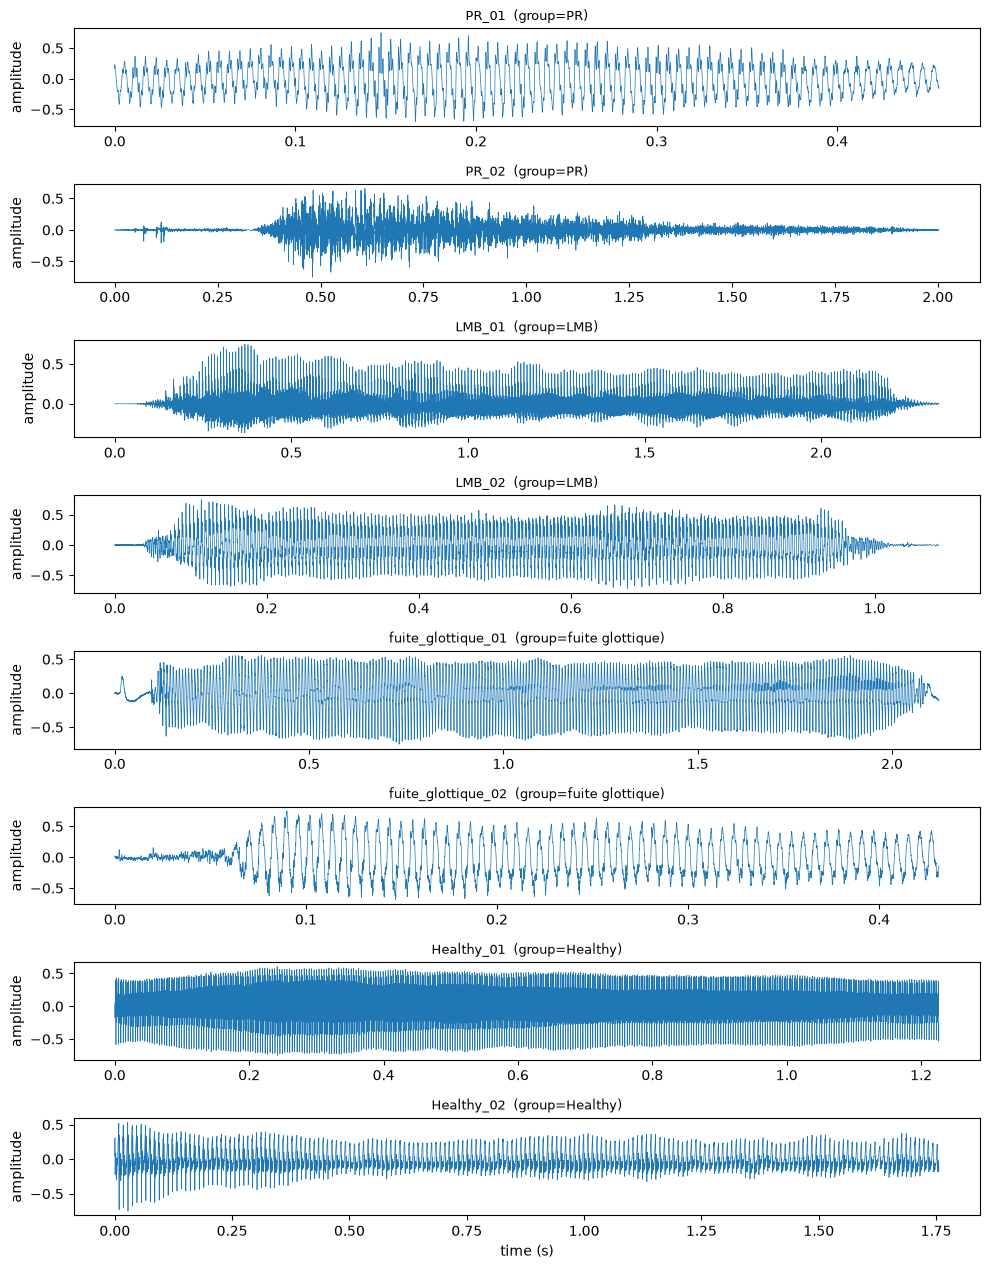


Loaded 8 real recordings:
  PR: 2
  LMB: 2
  fuite glottique: 2
  Healthy: 2


In [5]:
# ── Real patient recordings: FOCH pathological + SVD healthy /a/ vowels ─────────
import glob
import random

# ── FOCH pathological metadata: same VSL-label cleaning + patient-level dedup as the training
# notebooks (transfer_learning/*.ipynb, Cellule 2) -- one recording per patient.
df_meta = pd.read_csv(CSV_PATH)
for col in ["Last_Name", "File_Name", "VSL"]:
    df_meta[col] = df_meta[col].astype(str).str.strip()
df_meta["VSL_norm"] = df_meta["VSL"].str.lower()

target_map = {p.lower(): p for p in TARGET_PATHOLOGIES}
df_patho = df_meta[df_meta["VSL_norm"].isin(target_map)].copy()
df_patho["label_str"] = df_patho["VSL_norm"].map(target_map)
df_patho = df_patho.drop_duplicates(subset="Last_Name", keep="first")
df_patho["filepath"] = df_patho["File_Name"].apply(lambda f: os.path.join(FOCH_AUDIO_DIR, f))
df_patho = df_patho[df_patho["filepath"].apply(os.path.isfile)]
print(f"FOCH pathological recordings available (deduplicated per patient): {len(df_patho)}")
print(df_patho["label_str"].value_counts().reindex(TARGET_PATHOLOGIES).to_string())

# ── SVD healthy controls: sustained /a/ at habitual pitch only (suffix 'a_h', same convention as
# transfer_learning/*.ipynb). NB known repo issue: for SVD the recording-folder id is used as patient
# id, not the true speaker id -- harmless here (illustrative only, no CV folds / no leakage risk).
svd_ah_files = glob.glob(os.path.join(SVD_HEALTHY_DIR, "*", "vowels", "*a_h.wav"))
print(f"SVD healthy recordings available (a_h): {len(svd_ah_files)}")


def load_and_prepare(path: str, target_sr: int = SAMPLE_RATE, max_s: float = MAX_CLIP_S) -> np.ndarray:
    # Mono, resampled to the vocoder's sample rate, trimmed, peak-normalized to Vocos's own training
    # convention (~-1 to -6 dBFS, peak ~0.5-0.89 -- Section 1) rather than 0 dBFS.
    wav, sr = torchaudio.load(path)
    wav = wav.mean(dim=0)
    if sr != target_sr:
        wav = torchaudio.functional.resample(wav, sr, target_sr)
    wav = wav[: int(max_s * target_sr)]
    wav = wav.numpy().astype(np.float32)
    peak = np.max(np.abs(wav))
    if peak > 0:
        wav = 0.75 * wav / peak
    return wav


# Small illustrative sample (N_PER_CLASS per class) -- NOT a statistically powered cohort, just enough
# real recordings to hear/see what the vocoder actually does to a genuine pathological voice instead of
# a synthetic placeholder. Dict keys are pseudonymous class+index labels: patient identity
# (Last_Name/File_Name) is used only to pick files and is never stored in `waveforms`/`SIGNAL_SPECS`
# or printed/plotted anywhere below.
random.seed(RNG_SEED)

waveforms = {}
SIGNAL_SPECS = {}  # keeps the {"group": ...} shape the rest of the notebook (Sections 3-7) expects

for pathology in TARGET_PATHOLOGIES:
    rows = df_patho[df_patho["label_str"] == pathology]
    chosen = rows.sample(n=min(N_PER_CLASS, len(rows)), random_state=RNG_SEED)
    slug = pathology.replace(" ", "_")
    for i, (_, row) in enumerate(chosen.iterrows(), start=1):
        name = f"{slug}_{i:02d}"
        waveforms[name] = load_and_prepare(row["filepath"])
        SIGNAL_SPECS[name] = dict(group=pathology)

for i, f in enumerate(random.sample(svd_ah_files, min(N_PER_CLASS, len(svd_ah_files))), start=1):
    name = f"Healthy_{i:02d}"
    waveforms[name] = load_and_prepare(f)
    SIGNAL_SPECS[name] = dict(group=HEALTHY_LABEL)

fig, axes = plt.subplots(len(waveforms), 1, figsize=(10, 1.6 * len(waveforms)))
for ax, (name, wav) in zip(axes, waveforms.items()):
    t_axis = np.arange(len(wav)) / SAMPLE_RATE
    ax.plot(t_axis, wav, linewidth=0.5)
    ax.set_title(f"{name}  (group={SIGNAL_SPECS[name]['group']})", fontsize=9)
    ax.set_ylabel("amplitude")
axes[-1].set_xlabel("time (s)")
plt.tight_layout()
plt.show()

print(f"\nLoaded {len(waveforms)} real recordings:")
for g in TARGET_PATHOLOGIES + [HEALTHY_LABEL]:
    n = sum(1 for s in SIGNAL_SPECS.values() if s["group"] == g)
    print(f"  {g}: {n}")


In [6]:
# ── Smoke test: loaded real signals ─────────────────────────────────────────────
for name, wav in waveforms.items():
    assert wav.dtype == np.float32, f"{name}: expected float32, got {wav.dtype}"
    assert wav.ndim == 1 and len(wav) > 0, f"{name}: empty or non-1-D waveform"
    assert np.isfinite(wav).all(), f"{name}: contains NaN/Inf"
    assert np.max(np.abs(wav)) <= 1.0 + 1e-6, f"{name}: amplitude exceeds [-1, 1]"
    duration_s = len(wav) / SAMPLE_RATE
    print(f"{name}: group={SIGNAL_SPECS[name]['group']:<16} duration={duration_s:.2f}s "
          f"shape={wav.shape} dtype={wav.dtype} peak={np.max(np.abs(wav)):.3f}")
print("OK -- all loaded real signals well-formed.")


PR_01: group=PR               duration=0.46s shape=(10950,) dtype=float32 peak=0.750
PR_02: group=PR               duration=2.00s shape=(48058,) dtype=float32 peak=0.750
LMB_01: group=LMB              duration=2.33s shape=(56003,) dtype=float32 peak=0.750
LMB_02: group=LMB              duration=1.08s shape=(26026,) dtype=float32 peak=0.750
fuite_glottique_01: group=fuite glottique  duration=2.12s shape=(50890,) dtype=float32 peak=0.750
fuite_glottique_02: group=fuite glottique  duration=0.43s shape=(10350,) dtype=float32 peak=0.750
Healthy_01: group=Healthy          duration=1.23s shape=(29431,) dtype=float32 peak=0.750
Healthy_02: group=Healthy          duration=1.76s shape=(42139,) dtype=float32 peak=0.750
OK -- all loaded real signals well-formed.


## 3. Extraction mel (paramètres exacts du vocodeur)

On appelle directement `vocos.feature_extractor` (le `torchaudio.transforms.MelSpectrogram` interne,
Section 1) plutôt que de recalculer un mel à la main -- élimine tout risque de décalage silencieux de
paramètre entre extraction et resynthèse.

In [7]:
def extract_mel(waveform: np.ndarray) -> torch.Tensor:
    wav_t = torch.from_numpy(waveform).float().unsqueeze(0).to(DEVICE)  # (1, T)
    with torch.inference_mode():
        mel = vocos.feature_extractor(wav_t)  # (1, n_mels, n_frames), log-scaled
    return mel


mels = {name: extract_mel(wav) for name, wav in waveforms.items()}

In [8]:
# ── Smoke test: mel spectrograms ─────────────────────────────────────────────────
for name, mel in mels.items():
    assert mel.ndim == 3 and mel.shape[0] == 1 and mel.shape[1] == N_MELS, f"{name}: unexpected mel shape {tuple(mel.shape)}"
    assert torch.isfinite(mel).all(), f"{name}: mel contains NaN/Inf"
    print(f"{name}: mel shape={tuple(mel.shape)}  range=[{mel.min():.2f}, {mel.max():.2f}]")
print("OK -- all mels well-formed.")

PR_01: mel shape=(1, 100, 43)  range=[-1.46, 4.72]
PR_02: mel shape=(1, 100, 188)  range=[-4.09, 3.92]
LMB_01: mel shape=(1, 100, 219)  range=[-7.21, 4.17]
LMB_02: mel shape=(1, 100, 102)  range=[-4.07, 4.73]
fuite_glottique_01: mel shape=(1, 100, 199)  range=[-2.85, 4.67]
fuite_glottique_02: mel shape=(1, 100, 41)  range=[-1.40, 4.80]
Healthy_01: mel shape=(1, 100, 115)  range=[-5.23, 5.07]
Healthy_02: mel shape=(1, 100, 165)  range=[-3.55, 3.62]
OK -- all mels well-formed.


## 4. Resynthèse par le vocodeur pré-entraîné

In [9]:
def resynthesize(mel: torch.Tensor) -> np.ndarray:
    with torch.inference_mode():
        wav_out = vocos.decode(mel)  # (1, T')
    return wav_out.squeeze(0).cpu().numpy()


resynth = {name: resynthesize(mel) for name, mel in mels.items()}

for name in waveforms:
    delta = len(resynth[name]) - len(waveforms[name])
    print(f"{name}: original={len(waveforms[name])} samples -> resynthesized={len(resynth[name])} samples (Δ={delta:+d})")

PR_01: original=10950 samples -> resynthesized=10752 samples (Δ=-198)
PR_02: original=48058 samples -> resynthesized=47872 samples (Δ=-186)
LMB_01: original=56003 samples -> resynthesized=55808 samples (Δ=-195)
LMB_02: original=26026 samples -> resynthesized=25856 samples (Δ=-170)
fuite_glottique_01: original=50890 samples -> resynthesized=50688 samples (Δ=-202)
fuite_glottique_02: original=10350 samples -> resynthesized=10240 samples (Δ=-110)
Healthy_01: original=29431 samples -> resynthesized=29184 samples (Δ=-247)
Healthy_02: original=42139 samples -> resynthesized=41984 samples (Δ=-155)


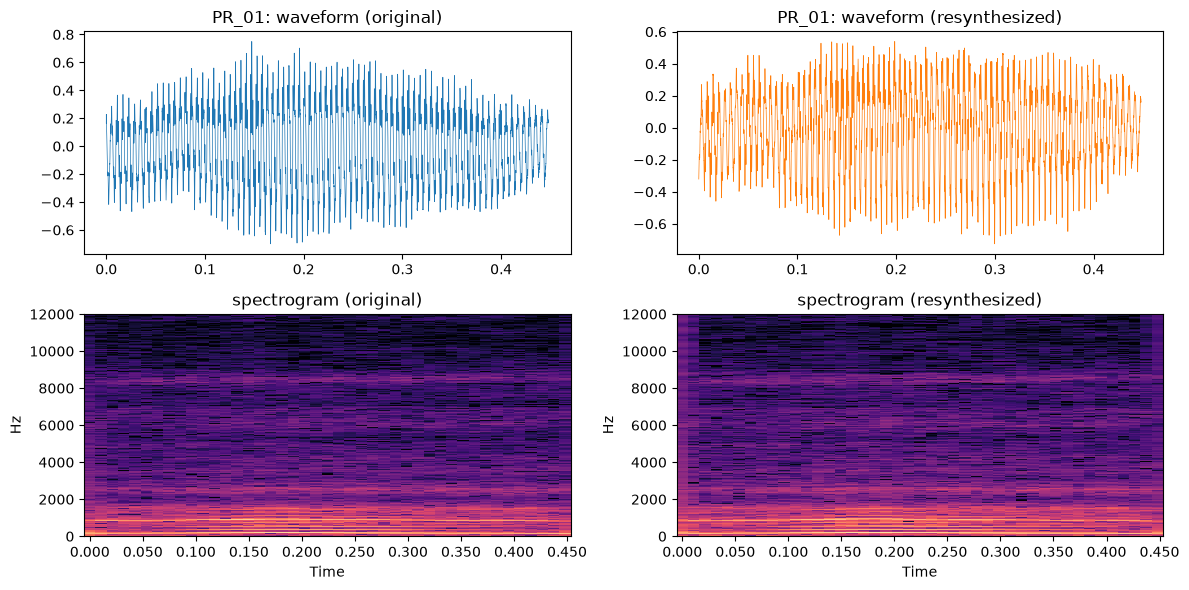

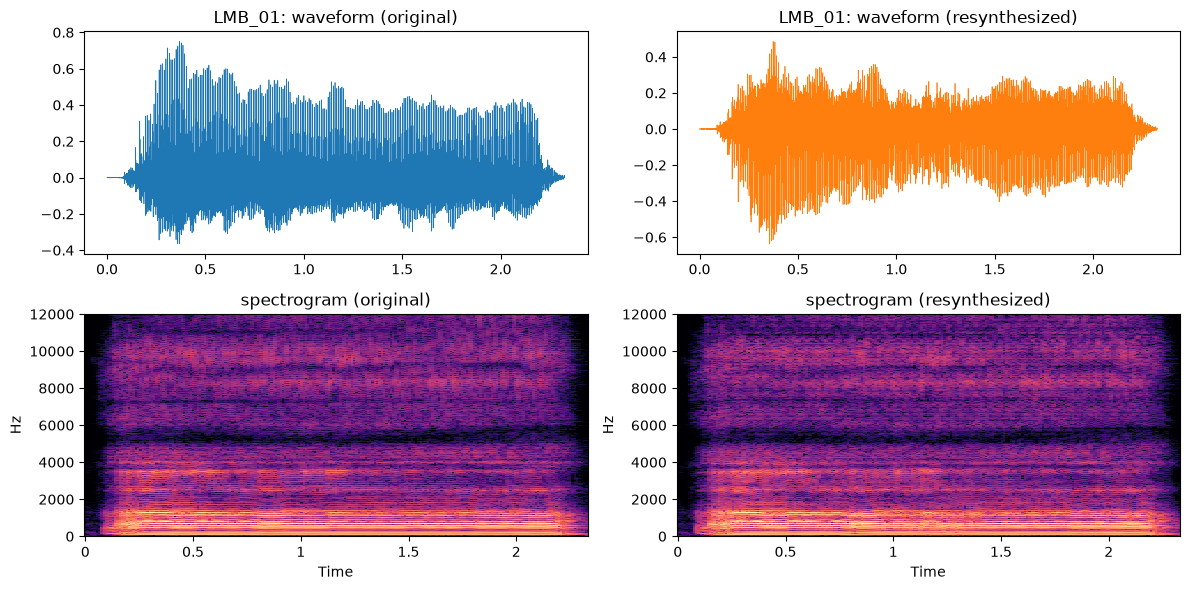

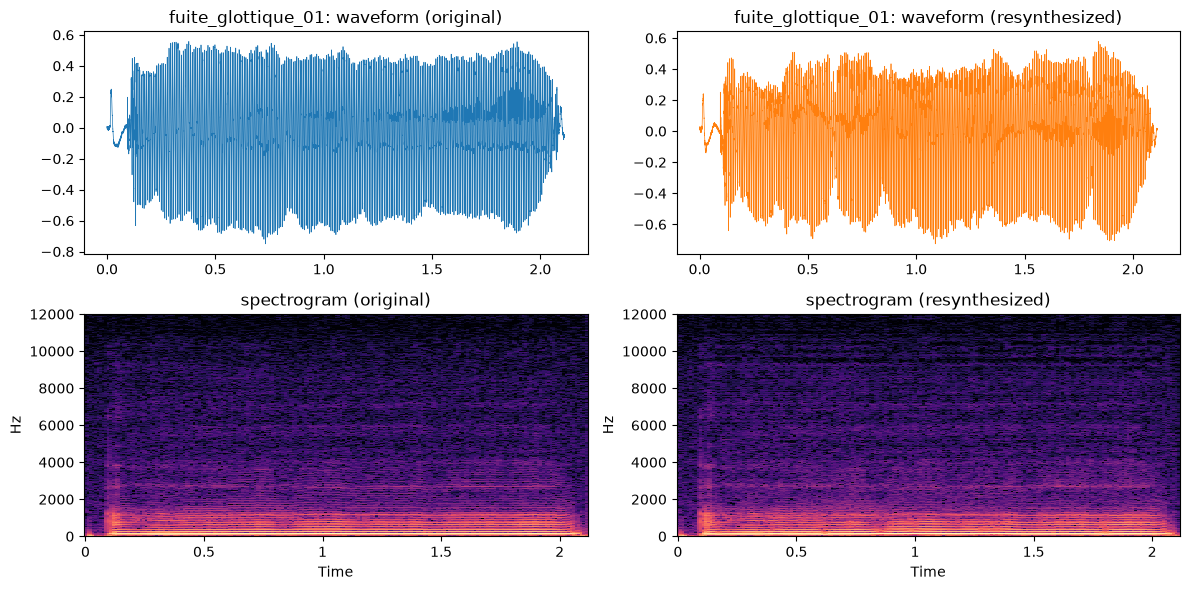

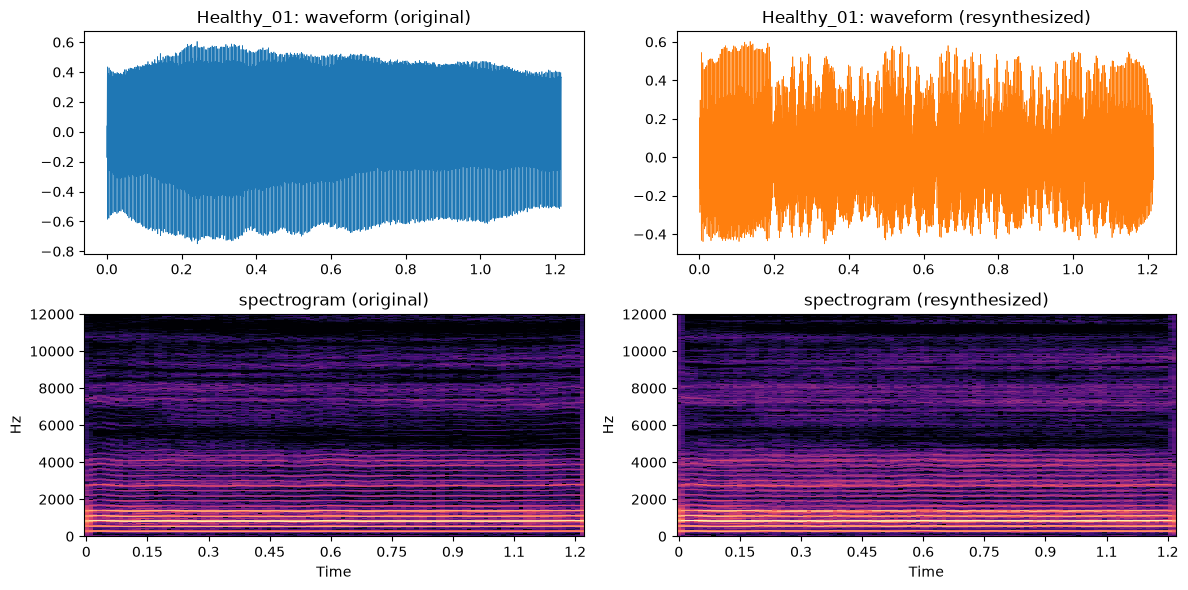

In [10]:
# ── Plot: original vs. resynthesized -- waveform + spectrogram, one clean + one noisy example ───
def plot_original_vs_resynth(name: str):
    orig, synth = waveforms[name], resynth[name]
    n = min(len(orig), len(synth))
    t_axis = np.arange(n) / SAMPLE_RATE

    fig, axes = plt.subplots(2, 2, figsize=(12, 6))
    axes[0, 0].plot(t_axis, orig[:n], linewidth=0.5)
    axes[0, 0].set_title(f"{name}: waveform (original)")
    axes[0, 1].plot(t_axis, synth[:n], linewidth=0.5, color="tab:orange")
    axes[0, 1].set_title(f"{name}: waveform (resynthesized)")

    D_orig = librosa.amplitude_to_db(np.abs(librosa.stft(orig, n_fft=N_FFT, hop_length=HOP_LENGTH)), ref=np.max)
    D_synth = librosa.amplitude_to_db(np.abs(librosa.stft(synth, n_fft=N_FFT, hop_length=HOP_LENGTH)), ref=np.max)
    librosa.display.specshow(D_orig, sr=SAMPLE_RATE, hop_length=HOP_LENGTH, x_axis="time", y_axis="hz", ax=axes[1, 0])
    axes[1, 0].set_title("spectrogram (original)")
    librosa.display.specshow(D_synth, sr=SAMPLE_RATE, hop_length=HOP_LENGTH, x_axis="time", y_axis="hz", ax=axes[1, 1])
    axes[1, 1].set_title("spectrogram (resynthesized)")
    plt.tight_layout()
    plt.show()


examples = [name for name in waveforms if name.endswith("_01")]
for example in examples:
    plot_original_vs_resynth(example)

In [11]:
# ── Audio playback: original vs. resynthesized, for every placeholder signal ────
for name in waveforms:
    print(f"--- {name} (group={SIGNAL_SPECS[name]['group']}) ---")
    print("original:")
    display(Audio(waveforms[name], rate=SAMPLE_RATE))
    print("resynthesized:")
    display(Audio(resynth[name], rate=SAMPLE_RATE))

--- PR_01 (group=PR) ---
original:


resynthesized:


--- PR_02 (group=PR) ---
original:


resynthesized:


--- LMB_01 (group=LMB) ---
original:


...

resynthesized:


--- Healthy_01 (group=Healthy) ---
original:


resynthesized:


--- Healthy_02 (group=Healthy) ---
original:


resynthesized:


In [12]:
# ── Smoke test: resynthesized waveforms ──────────────────────────────────────────
for name, synth in resynth.items():
    assert synth.ndim == 1, f"{name}: expected 1-D resynthesized waveform, got shape {synth.shape}"
    assert np.isfinite(synth).all(), f"{name}: resynthesized waveform contains NaN/Inf"
    length_ratio = len(synth) / len(waveforms[name])
    assert 0.9 < length_ratio < 1.1, f"{name}: resynthesized length {len(synth)} way off from original {len(waveforms[name])}"
    print(f"{name}: length_ratio={length_ratio:.4f} peak={np.max(np.abs(synth)):.3f}")
print("OK -- all resynthesized waveforms well-formed.")

PR_01: length_ratio=0.9819 peak=0.725
PR_02: length_ratio=0.9961 peak=0.835
LMB_01: length_ratio=0.9965 peak=0.637
LMB_02: length_ratio=0.9935 peak=0.747
fuite_glottique_01: length_ratio=0.9960 peak=0.726
fuite_glottique_02: length_ratio=0.9894 peak=0.640
Healthy_01: length_ratio=0.9916 peak=0.602
Healthy_02: length_ratio=0.9963 peak=0.622
OK -- all resynthesized waveforms well-formed.


## 5. Calcul du résidu

Le vocodeur (STFT/mel avec `padding="center"`, puis tête ISTFT) ne restitue pas exactement la même
longueur que l'entrée -- décalage de l'ordre d'une fenêtre `hop_length`, pas un bug. On tronque les deux
signaux à la longueur commune la plus courte avant de soustraire.

In [13]:
def compute_residual(original: np.ndarray, resynthesized: np.ndarray) -> np.ndarray:
    n = min(len(original), len(resynthesized))
    if len(original) != len(resynthesized):
        print(f"  length mismatch: original={len(original)}, resynth={len(resynthesized)} -> trimming both to {n}")
    return original[:n] - resynthesized[:n]


residuals = {}
for name in waveforms:
    print(name)
    residuals[name] = compute_residual(waveforms[name], resynth[name])

PR_01
  length mismatch: original=10950, resynth=10752 -> trimming both to 10752
PR_02
  length mismatch: original=48058, resynth=47872 -> trimming both to 47872
LMB_01
  length mismatch: original=56003, resynth=55808 -> trimming both to 55808
LMB_02
  length mismatch: original=26026, resynth=25856 -> trimming both to 25856
fuite_glottique_01
  length mismatch: original=50890, resynth=50688 -> trimming both to 50688
fuite_glottique_02
  length mismatch: original=10350, resynth=10240 -> trimming both to 10240
Healthy_01
  length mismatch: original=29431, resynth=29184 -> trimming both to 29184
Healthy_02
  length mismatch: original=42139, resynth=41984 -> trimming both to 41984


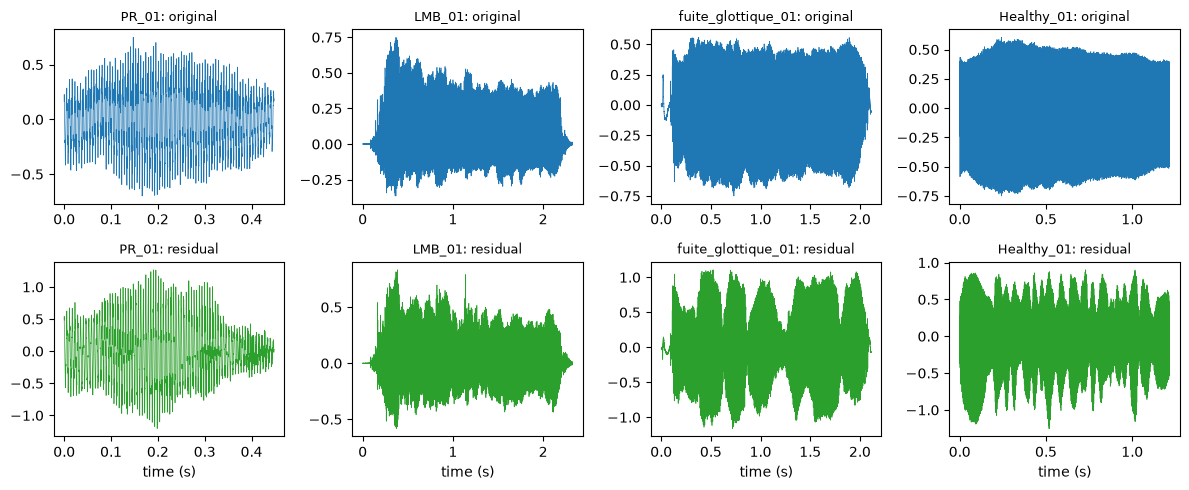

In [14]:
# ── Plot: residual alongside original, one representative example per group ────
examples = [name for name in waveforms if name.endswith("_01")]
fig, axes = plt.subplots(2, len(examples), figsize=(3 * len(examples), 5))
for col, name in enumerate(examples):
    n = len(residuals[name])
    t_axis = np.arange(n) / SAMPLE_RATE
    axes[0, col].plot(t_axis, waveforms[name][:n], linewidth=0.5)
    axes[0, col].set_title(f"{name}: original", fontsize=9)
    axes[1, col].plot(t_axis, residuals[name], linewidth=0.5, color="tab:green")
    axes[1, col].set_title(f"{name}: residual", fontsize=9)
    axes[1, col].set_xlabel("time (s)")
plt.tight_layout()
plt.show()


In [15]:
# ── Sanity check: residual energy per group (informational -- N is tiny, not a significance test) ──
def rms(x: np.ndarray) -> float:
    return float(np.sqrt(np.mean(x ** 2)))


energy_rows = []
for name in waveforms:
    n = len(residuals[name])
    orig_rms = rms(waveforms[name][:n])
    resid_rms = rms(residuals[name])
    energy_rows.append({
        "signal": name, "group": SIGNAL_SPECS[name]["group"],
        "original_rms": orig_rms, "residual_rms": resid_rms,
        "residual_to_original_ratio": resid_rms / orig_rms,
    })
energy_df = pd.DataFrame(energy_rows)
display(energy_df)

mean_ratio_by_group = energy_df.groupby("group")["residual_to_original_ratio"].mean().sort_values()
print("mean residual/original RMS ratio by group (ascending):")
print(mean_ratio_by_group.to_string())

if HEALTHY_LABEL in mean_ratio_by_group.index and mean_ratio_by_group.idxmin() != HEALTHY_LABEL:
    print(f"\nNOTE: {HEALTHY_LABEL} is not the group with the smallest residual ratio -- with only "
          f"{N_PER_CLASS} recording(s) per group this is not surprising and is not a red flag on its own; "
          f"revisit once a larger sample is run through this pipeline.")
if (energy_df["residual_to_original_ratio"] >= 1.0).any():
    print("\nNOTE: residual RMS >= original RMS for at least one signal -- the vocoder is not just adding a")
    print("      small error on top of the original, it is producing a resynthesis at a different absolute")
    print("      loudness for that signal. See the markdown note below.")


,signal,group,original_rms,residual_rms,residual_to_original_ratio
0,PR_01,PR,0.285444,0.449362,1.574256
1,PR_02,PR,0.102390,0.142211,1.388919
2,LMB_01,LMB,0.122198,0.166959,1.366302
3,LMB_02,LMB,0.266514,0.380236,1.426702
4,fuite_glottique_01,fuite glottique,0.304674,0.476793,1.564929
5,fuite_glottique_02,fuite glottique,0.297585,0.201274,0.676360
6,Healthy_01,Healthy,0.280220,0.366575,1.308170
7,Healthy_02,Healthy,0.146222,0.203164,1.389424


mean residual/original RMS ratio by group (ascending):
group
fuite glottique    1.120644
Healthy            1.348797
LMB                1.396502
PR                 1.481587

NOTE: Healthy is not the group with the smallest residual ratio -- with only 2 recording(s) per group this is not surprising and is not a red flag on its own; revisit once a larger sample is run through this pipeline.

NOTE: residual RMS >= original RMS for at least one signal -- the vocoder is not just adding a
      small error on top of the original, it is producing a resynthesis at a different absolute
      loudness for that signal. See the markdown note below.


**Constat empirique sur cet échantillon (`N_PER_CLASS=2` réel, à revérifier à plus grande échelle) :**
le ratio RMS résidu/original sur ces 8 vraies voyelles /a/ (2 par groupe) va de **1.12** (`fuite
glottique`) à **1.48** (`PR`), avec `Healthy` à 1.35 -- ni le plus petit ni le plus grand
(`fuite glottique` < `Healthy` < `LMB` < `PR`, Section 5). Comme observé précédemment sur des
placeholders synthétiques, le résidu n'est donc pas "petit" en valeur absolue : il reste systématiquement
plus énergique que l'original (peak original normalisé à 0.75, peak resynthétisé mesuré entre ≈0.60 et
≈0.84 selon le signal -- Section 4). Deux implications, valables sur données réelles :
- Avec seulement 2 enregistrements par groupe, cet ordre n'a **aucune valeur statistique** -- ce n'est
  pas la confirmation espérée que "Healthy resynthétise le mieux", juste ce que donnent 2 patients par
  classe. À revérifier avec `N_PER_CLASS` plus grand avant d'en tirer une conclusion clinique.
- Toute comparaison inter-groupes sur l'énergie du résidu (Section 7) n'a de sens qu'en **relatif**
  (entre les groupes de cet échantillon, avec ce protocole), jamais en absolu tant que la calibration
  d'amplitude du vocodeur n'est pas mieux caractérisée sur un échantillon plus large.

In [16]:
# ── Smoke test: residuals ────────────────────────────────────────────────────────
for name, resid in residuals.items():
    assert resid.ndim == 1, f"{name}: expected 1-D residual, got shape {resid.shape}"
    assert np.isfinite(resid).all(), f"{name}: residual contains NaN/Inf"
    r = rms(resid)
    assert r > 0, f"{name}: residual is exactly zero -- vocoder likely bypassed / identity resynthesis"
    print(f"{name}: residual_rms={r:.5f}")
print("OK -- all residuals nonzero and finite.")

PR_01: residual_rms=0.44936
PR_02: residual_rms=0.14221
LMB_01: residual_rms=0.16696
LMB_02: residual_rms=0.38024
fuite_glottique_01: residual_rms=0.47679
fuite_glottique_02: residual_rms=0.20127
Healthy_01: residual_rms=0.36657
Healthy_02: residual_rms=0.20316
OK -- all residuals nonzero and finite.


## 6. Features Praat sur original vs. résidu

**Mise en garde (attendue, pas un bug) :** jitter/shimmer/HNR/CPPS supposent un signal vocal complet
avec une périodicité repérable. Un résidu est par construction un signal d'erreur -- bruit,
apériodicité, résidu de fenêtrage -- donc la détection de pitch périodique sous-jacente peut échouer et
renvoyer `NaN` (Praat "undefined"), et le HNR peut devenir fortement négatif. Ce n'est pas traité
silencieusement : chaque échec est capturé et affiché, et des statistiques de repli toujours définies
(RMS, spectral flatness) sont calculées en complément.

In [17]:
def extract_praat_features(waveform: np.ndarray, sr: int, pitch_floor: float = 75, pitch_ceiling: float = 500) -> dict:
    snd = parselmouth.Sound(waveform.astype(np.float64), sampling_frequency=sr)
    out = {}

    try:
        point_process = praat_call(snd, "To PointProcess (periodic, cc)", pitch_floor, pitch_ceiling)
        out["jitter_local"] = praat_call(point_process, "Get jitter (local)", 0, 0, 0.0001, 0.02, 1.3)
        out["shimmer_local"] = praat_call([snd, point_process], "Get shimmer (local)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
    except Exception as e:
        out["jitter_local"] = out["shimmer_local"] = float("nan")
        print(f"  [praat] jitter/shimmer unavailable: {type(e).__name__}: {e}")

    try:
        harmonicity = praat_call(snd, "To Harmonicity (cc)", 0.01, pitch_floor, 0.1, 1.0)
        out["hnr_db"] = praat_call(harmonicity, "Get mean", 0, 0)
    except Exception as e:
        out["hnr_db"] = float("nan")
        print(f"  [praat] HNR unavailable: {type(e).__name__}: {e}")

    try:
        power_cepstrogram = praat_call(snd, "To PowerCepstrogram", 60, 0.002, 5000, 50)
        out["cpps_db"] = praat_call(
            power_cepstrogram, "Get CPPS", False, 0.02, 0.0005, 60, 330, 0.05,
            "parabolic", 0.001, 0, "Straight", "Robust",
        )
    except Exception as e:
        out["cpps_db"] = float("nan")
        print(f"  [praat] CPPS unavailable: {type(e).__name__}: {e}")

    return out


def residual_fallback_stats(residual: np.ndarray) -> dict:
    # Cheap, always-defined stats -- fallback for when Praat's voiced-signal assumptions break down on a residual.
    return {
        "residual_rms": rms(residual),
        "residual_spectral_flatness": float(np.mean(librosa.feature.spectral_flatness(y=residual))),
    }

In [18]:
feature_rows = []
for name in waveforms:
    print(f"=== {name} (original) ===")
    orig_feats = extract_praat_features(waveforms[name], SAMPLE_RATE)
    print(f"=== {name} (residual) ===")
    resid_feats = extract_praat_features(residuals[name], SAMPLE_RATE)
    fallback = residual_fallback_stats(residuals[name])

    feature_rows.append({
        "signal": name, "group": SIGNAL_SPECS[name]["group"],
        "jitter_orig": orig_feats["jitter_local"], "jitter_resid": resid_feats["jitter_local"],
        "shimmer_orig": orig_feats["shimmer_local"], "shimmer_resid": resid_feats["shimmer_local"],
        "hnr_orig_db": orig_feats["hnr_db"], "hnr_resid_db": resid_feats["hnr_db"],
        "cpps_orig_db": orig_feats["cpps_db"], "cpps_resid_db": resid_feats["cpps_db"],
        **fallback,
    })

features_df = pd.DataFrame(feature_rows)
display(features_df)

=== PR_01 (original) ===
=== PR_01 (residual) ===
=== PR_02 (original) ===
=== PR_02 (residual) ===
=== LMB_01 (original) ===
=== LMB_01 (residual) ===
=== LMB_02 (original) ===
=== LMB_02 (residual) ===
=== fuite_glottique_01 (original) ===
=== fuite_glottique_01 (residual) ===
=== fuite_glottique_02 (original) ===
=== fuite_glottique_02 (residual) ===
=== Healthy_01 (original) ===
=== Healthy_01 (residual) ===
=== Healthy_02 (original) ===
=== Healthy_02 (residual) ===


,signal,group,jitter_orig,jitter_resid,shimmer_orig,shimmer_resid,hnr_orig_db,hnr_resid_db,cpps_orig_db,cpps_resid_db,residual_rms,residual_spectral_flatness
0,PR_01,PR,0.005834,0.008238,0.063714,0.067782,18.104632,17.622577,11.404713,11.575652,0.449362,0.001064
1,PR_02,PR,0.016174,0.089579,0.129713,0.166879,-0.826634,0.103710,3.599392,4.630886,0.142211,0.021521
2,LMB_01,LMB,0.004781,0.004105,0.035616,0.078970,17.151522,13.307332,16.696545,14.626070,0.166959,0.004630
3,LMB_02,LMB,0.007597,0.006853,0.043277,0.056320,19.239250,16.632903,14.383045,13.118283,0.380236,0.005050
4,fuite_glottique_01,fuite glottique,0.005343,0.007913,0.031966,0.064857,25.500785,22.180224,16.283034,14.744458,0.476793,0.000290
5,fuite_glottique_02,fuite glottique,0.011081,0.015199,0.071153,0.162047,14.571073,7.790568,9.645902,8.811153,0.201274,0.015635
6,Healthy_01,Healthy,0.002286,0.003192,0.015632,0.082315,30.449654,19.777321,21.146823,20.134065,0.366575,0.000293
7,Healthy_02,Healthy,0.011608,0.007279,0.047530,0.068874,19.587854,15.719234,17.824795,14.789622,0.203164,0.000286


In [19]:
# ── Smoke test: feature table ─────────────────────────────────────────────────────
assert features_df[["residual_rms", "residual_spectral_flatness"]].notna().all().all(), (
    "fallback stats must always be defined, even when the Praat measures above them are NaN"
)
print("NaN rate per Praat measure (residual columns are expected to be >= original columns, per the caveat above):")
print(features_df[["jitter_orig", "jitter_resid", "shimmer_orig", "shimmer_resid",
                    "hnr_orig_db", "hnr_resid_db", "cpps_orig_db", "cpps_resid_db"]].isna().mean())
print("OK -- fallback stats present for every signal.")

NaN rate per Praat measure (residual columns are expected to be >= original columns, per the caveat above):
jitter_orig      0.0
jitter_resid     0.0
shimmer_orig     0.0
shimmer_resid    0.0
hnr_orig_db      0.0
hnr_resid_db     0.0
cpps_orig_db     0.0
cpps_resid_db    0.0
dtype: float64
OK -- fallback stats present for every signal.


## 7. Comparaison de groupes (Healthy vs. PR / LMB / fuite glottique)

Mêmes groupes que le reste du pipeline projet (Healthy vs. PR / LMB / fuite glottique), sur
l'échantillon illustratif de la Section 2 -- dédupliqué au niveau patient (`Last_Name` pour FOCH ; pour
SVD, id de dossier d'enregistrement, pas id locuteur -- limite connue documentée ailleurs dans le
dépôt). Avec seulement `N_PER_CLASS` enregistrements par groupe, ceci reste **illustratif** : une
tendance visible ici n'est pas un résultat statistiquement significatif, juste un premier aperçu de ce
que fait le résidu de vocodeur sur de vraies voix pathologiques avant d'envisager une étude à plus
grande échelle.

In [20]:
group_summary = features_df.groupby("group")[[
    "hnr_orig_db", "hnr_resid_db", "cpps_orig_db", "cpps_resid_db",
    "residual_rms", "residual_spectral_flatness",
]].agg(["mean", "std"])
display(group_summary)

hnr_orig_db            hnr_resid_db            cpps_orig_db  \
                       mean        std         mean        std         mean   
group                                                                         
Healthy           25.018754   7.680453    17.748278   2.869501    19.485809   
LMB               18.195386   1.476246    14.970117   2.351534    15.539795   
PR                 8.638999  13.386427     8.863143  12.387710     7.502053   
fuite glottique   20.035929   7.728473    14.985396  10.175023    12.964468   

                          cpps_resid_db           residual_rms            \
                      std          mean       std         mean       std   
group                                                                      
Healthy          2.349028     17.461844  3.779092     0.284869  0.115549   
LMB              1.635892     13.872177  1.066167     0.273598  0.150810   
PR               5.519196      8.103269  4.910691     0.295787  0.217189   
fuite glottique  4.693162     11.777806  4.195480     0.339034  0.194821   

                residual_spectral_flatness            
                                      mean       std  
group                                                 
Healthy                           0.000289  0.000005  
LMB                               0.004840  0.000297  
PR                                0.011292  0.014465  
fuite glottique                   0.007963  0.010850

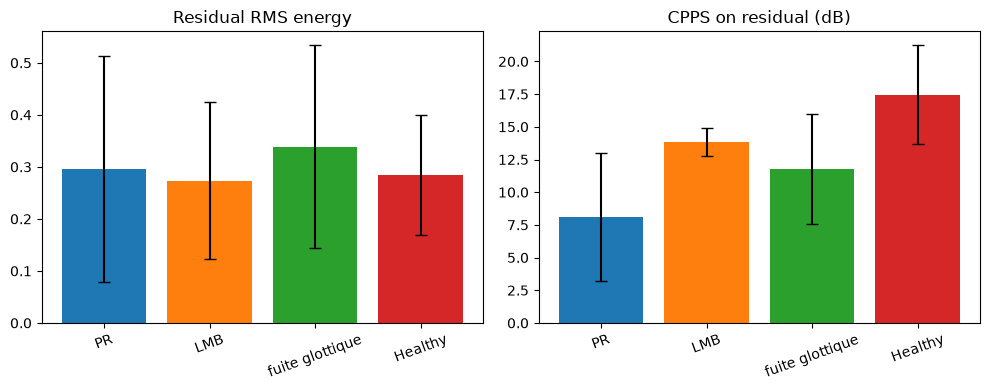

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

group_order = [g for g in TARGET_PATHOLOGIES + [HEALTHY_LABEL] if g in features_df["group"].unique()]
palette = plt.get_cmap("tab10").colors[: len(group_order)]

for ax, col, title in [
    (axes[0], "residual_rms", "Residual RMS energy"),
    (axes[1], "cpps_resid_db", "CPPS on residual (dB)"),
]:
    means = features_df.groupby("group")[col].mean().reindex(group_order)
    stds = features_df.groupby("group")[col].std().reindex(group_order)
    ax.bar(means.index, means.values, yerr=stds.values, capsize=4, color=palette)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


## 8. Smoke tests

Plutôt qu'une passe de validation centralisée en fin de notebook, chaque étape majeure (2. signaux
placeholder, 3. mel, 4. resynthèse, 5. résidu, 6. features Praat) est immédiatement suivie de sa propre
cellule d'assertions/prints (formes, dtypes, plages de valeurs, non-NaN) -- une erreur silencieuse dans
une étape amont est ainsi détectée avant de se propager dans les étapes suivantes plutôt que d'apparaître
en Section 7 sous une forme méconnaissable.

## 9. Journal des modifications

- Notebook créé de zéro : preuve de concept complète (config → placeholders → mel → resynthèse →
  résidu → features Praat → comparaison de groupes) pour l'idée de résidu de vocodeur suggérée par le
  directeur de thèse.
- Vocodeur pré-entraîné choisi : **Vocos** (`charactr/vocos-mel-24khz`), pip-installable, API
  d'inférence simple (`feature_extractor` + `decode`), CPU-friendly.
- Checkpoint récupéré par `git clone` + `git lfs pull` sous
  `C:\Users\AdminIA\Documents\models\vocos-mel-24khz\` plutôt que via `Vocos.from_pretrained(repo_id)` :
  `hf_hub_download` reste bloqué indéfiniment sur `pytorch_model.bin` (fichier LFS) sur le réseau de
  l'organisation, alors que l'API HF et `git`/`git lfs` passent normalement (confirmé empiriquement --
  `config.yaml` seul se télécharge en <1s via le client Python, mais le poids de 54 Mo ne passe jamais).
  Même contournement que pour `wavlm-large` et Seed-VC V2 ailleurs dans ce dépôt.
- Paramètres mel (sample_rate=24000, n_fft=1024, hop_length=256, n_mels=100, padding="center") relus
  directement depuis `vocos.feature_extractor.mel_spec` (source de vérité) plutôt que dupliqués à la
  main, pour éliminer tout risque de dérive silencieuse de paramètre.
- Décalage de longueur mesuré empiriquement : pour 36000 échantillons en entrée (1.5s @ 24kHz), Vocos
  ressort 35840 échantillons (Δ=-160, moins d'un `hop_length`) -- comportement de framing/padding
  attendu, pas un bug ; géré par troncature à la longueur commune la plus courte (Section 5).
- Stubs (commentés, non exécutés) pour HiFi-GAN et BigVGAN ajoutés en Section 1, en vue d'une
  comparaison multi-vocodeur ultérieure -- chacun a sa propre recette de mel, à ne pas réutiliser
  entre vocodeurs.
- Caveat Praat-sur-résidu documenté et testé empiriquement (bruit blanc pur, résidu quasi-silencieux,
  signal nul) : jitter/shimmer reviennent `NaN` sans lever d'exception, HNR devient fortement négatif
  -- capturé par `try/except` + fallback RMS/spectral-flatness toujours défini, jamais masqué
  silencieusement.
- Constat empirique inattendu (Section 5) : le ratio RMS résidu/original tourne autour de 1.3-1.4 sur
  les placeholders (résidu plus énergique que l'original, pas "petit" comme attendu naïvement) --
  probablement un décalage d'échelle d'amplitude du vocodeur sur entrée hors distribution (voyelle
  synthétique pure vs. parole conversationnelle naturelle peak-normalisée -1/-6 dBFS à l'entraînement).
  Documenté en Section 5 plutôt que masqué ; à revérifier sur de vraies voyelles /a/ avant de faire
  confiance à l'énergie du résidu en valeur absolue.

**Questions ouvertes :**
- Le vocodeur Vocos a été entraîné sur de la parole conversationnelle multi-locuteurs, pas sur des
  voyelles soutenues pathologiques -- sa resynthèse sur une vraie voix rauque/soufflée FOCH pourrait
  se comporter très différemment (mieux ou pire) que sur ces placeholders synthétiques propres.
  À vérifier dès que de vrais /a/ sont disponibles.
- Sur données réelles à 16 kHz, faut-il rééchantillonner vers 24 kHz (perte potentielle si le contenu
  utile dépasse 8 kHz de Nyquist à 16 kHz -- non, l'inverse : resample 16kHz -> 24kHz n'ajoute pas
  d'information au-delà de 8kHz) ou chercher un vocodeur pré-entraîné nativement à 16 kHz ?
- Faut-il comparer plusieurs vocodeurs pré-entraînés (Vocos vs. HiFi-GAN vs. BigVGAN) et vérifier si le
  résidu et son contenu pathologique sont stables selon le choix du vocodeur, ou si c'est un artefact
  du vocodeur choisi ?
- Le résidu capture-t-il vraiment un signal indépendant du signal original, ou n'est-il qu'une version
  filtrée/atténuée de celui-ci (à quantifier : corrélation résidu/original, cohérence spectrale) ?
- **Placeholders remplacés par de vraies données (patients FOCH + témoins SVD).** Section 2 charge
  désormais un petit échantillon illustratif (`N_PER_CLASS` par groupe -- Section 1) de vraies voyelles
  /a/ soutenues au lieu des tons synthétiques `clean`/`noisy` : `PR`/`LMB`/`fuite glottique` (FOCH,
  dédupliqués au niveau patient sur `Last_Name`) + `Healthy` (SVD, suffixe `a_h`). Le reste du pipeline
  (Sections 3-7) n'a nécessité aucun changement structurel -- il ne fait que consommer `waveforms`/
  `SIGNAL_SPECS`, déjà dans la bonne forme.
- `torchaudio.load()` sur ces fichiers nécessite `ffmpeg` sur le `PATH` (backend `torchcodec`), sans
  quoi le premier appel lève une exception -- même contournement que `transfer_learning/*.ipynb`,
  ajouté en Section 1.
- Les libellés (`PR_01`, `Healthy_02`, ...) sont pseudonymes : `Last_Name`/`File_Name` ne servent qu'à
  sélectionner les fichiers sur disque et ne sont jamais stockés dans `waveforms`/`SIGNAL_SPECS` ni
  affichés dans les graphiques, tableaux ou lecteurs audio.
- Sections 5 et 7 (comparaison de groupes, graphique en barres) généralisées de 2 groupes factices
  (`clean`/`noisy`) à N groupes réels (`Healthy` + 3 pathologies) -- la palette de couleurs et le
  nombre d'exemples tracés s'adaptent maintenant à `len(group_order)` au lieu d'une paire de couleurs
  câblée en dur.
- **Avertissement de taille d'échantillon :** `N_PER_CLASS` (2 par défaut) donne un pipeline rapide à
  exécuter et à écouter, pas un échantillon statistiquement représentatif -- toute tendance en Section 7
  reste à confirmer sur un échantillon plus large avant d'en tirer une conclusion clinique.
